
# Ad hoc statistické ověření produktových kategorií

## Kontext analýzy

V hlavní produktové analýze provedené pomocí SQL a Power BI se nepodařilo identifikovat konkrétní produkt jako jednoznačný driver věrnosti zákazníků.  
Proto bylo následně provedeno rychlé ad hoc statistické ověření v Pythonu, zda se vztah k návratnosti neprojevuje alespoň na vyšší úrovni produktových kategorií.

Cílem této analýzy je ověřit:

> Existuje souvislost mezi kategorií prvního zakoupeného produktu a návratností zákazníka?

Pro ověření byl použit χ² test nezávislosti.


## 1. Import knihoven

Načtení základních knihoven pro práci s daty, statistické testování a vizualizaci.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

## 2. Načtení datasetu

Načtení denormalizovaného datasetu e-shopu, který byl použit také v SQL a Power BI části projektu.


In [2]:
df=pd.read_csv('denormalizovany_dataset.csv')

## 3. Identifikace první objednávky zákazníka

Nejprve je potřeba určit první objednávku každého zákazníka.  
Dataset obsahuje více řádků na objednávku (produkty), proto jsou data nejdříve agregována na úroveň objednávky.

Následně je pro každého zákazníka vybrána jeho první objednávka a první produktová kategorie.


In [3]:
orders = (
    df.sort_values(['id_zakaznik', 'datum', 'id_objednavky'])
      .groupby(['id_zakaznik', 'id_objednavky', 'datum'], as_index=False)
      .agg({'druh': 'first'})
)

first_orders = (
    orders.sort_values(['id_zakaznik', 'datum', 'id_objednavky'])
          .groupby('id_zakaznik')
          .first()
          .reset_index()
)

## 4. Vytvoření návratnostního flagu

Pro každého zákazníka je vytvořen příznak:

- `1` = zákazník provedl více než jednu objednávku
- `0` = zákazník provedl pouze jednu objednávku

Tento flag bude použit pro statistické testování návratnosti.


In [4]:
returns = (
    df.groupby('id_zakaznik')['id_objednavky']
      .nunique()
      .gt(1)
      .astype(int)
      .reset_index(name='return_flag')
)

## 5. Spojení dat

Spojení informací o první kategorii zákazníka a jeho návratnosti do jednoho datasetu.


In [5]:
customer_df = first_orders.merge(
    returns,
    on='id_zakaznik'
)

## 6. Příprava finálního datasetu

Výběr pouze sloupců potřebných pro statistické testování.


In [6]:
customer_df = customer_df[
    ['id_zakaznik', 'druh', 'return_flag']
].rename(columns={'druh': 'kategorie'})

## 7. Import statistického testu

Import χ² testu nezávislosti ze scipy.


In [7]:
from scipy.stats import chi2_contingency

## 8. Kontingenční tabulka a χ² test

Vytvoření kontingenční tabulky mezi:

- kategorií prvního nákupu
- návratností zákazníka

Následně je proveden χ² test nezávislosti.


In [8]:
ct = pd.crosstab(
    customer_df['kategorie'],
    customer_df['return_flag']
)

chi2, p, dof, expected = chi2_contingency(ct)

ct

return_flag,0,1
kategorie,,
bytový doplňek,16,43
doplněk,208,713
hračka,103,334
oblečení,756,2691


## 9. Výpočet návratnosti podle kategorií

Výpočet procentuální návratnosti zákazníků v jednotlivých kategoriích.


In [9]:
return_rates = (
    ct.div(ct.sum(axis=1), axis=0) * 100
)

display(return_rates)

return_flag,0,1
kategorie,,
bytový doplňek,27.118644,72.881356
doplněk,22.584148,77.415852
hračka,23.569794,76.430206
oblečení,21.932115,78.067885


## 10. Interpretace statistického testu

Vyhodnocení p-value a interpretace výsledku χ² testu.


In [10]:
print(f"Chi-squared: {chi2:.2f}, p-value: {p:.4f}")

alpha = 0.05

if p < alpha:
    print("Závěr: Existuje statisticky významná souvislost mezi kategorií a návratností zákazníků.")
else:
    print("Závěr: Nebyla prokázána statisticky významná souvislost mezi kategorií a návratností zákazníků.")

Chi-squared: 1.51, p-value: 0.6805
Závěr: Nebyla prokázána statisticky významná souvislost mezi kategorií a návratností zákazníků.


## 11. Vizualizace výsledků

Sloupcový graf zobrazující návratnost zákazníků podle první zakoupené kategorie.


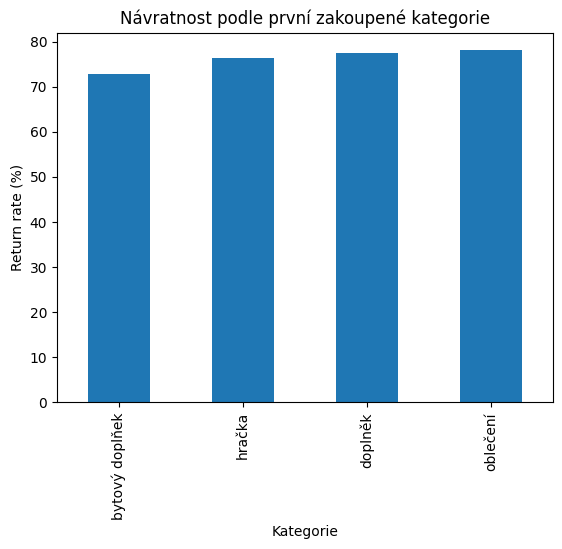

In [11]:
import matplotlib.pyplot as plt

return_rates[1].sort_values().plot(kind='bar')

plt.ylabel('Return rate (%)')
plt.xlabel('Kategorie')
plt.title('Návratnost podle první zakoupené kategorie')

plt.show()


# Závěr

χ² test ukázal statisticky významnou souvislost mezi kategorií prvního zakoupeného produktu a návratností zákazníků.

Praktický význam tohoto vztahu se však ukázal jako velmi slabý a následná detailnější produktová analýza neidentifikovala žádný konkrétní produkt ani produktovou kategorii jako jednoznačný driver věrnosti zákazníků.

Výsledky proto naznačují, že návratnost zákazníků není primárně řízena konkrétním produktem nebo kategorií, ale spíše celkovým nákupním chováním zákazníků v čase.
